In [1]:
import pandas as pd

knn_df = pd.read_csv("knn/all_crops_summary_knn.csv")[["crop", "acc_mean", "f1_mean", "n_rows", "n_classes"]].add_suffix("_knn").rename(columns={"crop_knn": "crop"})
rf_df  = pd.read_csv("random_forest/all_crops_summary_random_forest.csv")[["crop", "acc_mean", "f1_mean"]].add_suffix("_rf").rename(columns={"crop_rf": "crop"})
xgb_df = pd.read_csv("xgboost/all_crops_summary_xgboost.csv")[["crop", "acc_mean", "f1_mean"]].add_suffix("_xgb").rename(columns={"crop_xgb": "crop"})

merged = knn_df.merge(rf_df, on="crop").merge(xgb_df, on="crop")
merged["f1_avg_all"] = merged[["f1_mean_knn", "f1_mean_rf", "f1_mean_xgb"]].mean(axis=1)
merged["consistently_low"] = merged["f1_avg_all"] < 0.50  # adjust threshold

print(merged.sort_values("f1_avg_all")[["crop", "n_rows_knn", "n_classes_knn", "f1_mean_knn", "f1_mean_rf", "f1_mean_xgb", "f1_avg_all", "consistently_low"]].to_string(index=False))
merged.to_csv("cross_model_crop_comparison.csv", index=False)

                crop  n_rows_knn  n_classes_knn  f1_mean_knn  f1_mean_rf  f1_mean_xgb  f1_avg_all  consistently_low
       other_cereals         229              3     0.593948    0.624157     0.622208    0.613438             False
               maize         723              3     0.614478    0.594624     0.661812    0.623638             False
             sesamum         686              3     0.638644    0.618109     0.621514    0.626089             False
           safflower         247              3     0.650175    0.607380     0.626461    0.628005             False
 other_kharif_pulses         586              3     0.662587    0.584786     0.669938    0.639104             False
               moong         675              3     0.688228    0.546149     0.692935    0.642437             False
                gram         641              3     0.704344    0.550609     0.679519    0.644824             False
           arhar_tur         665              3     0.686317    0.578818

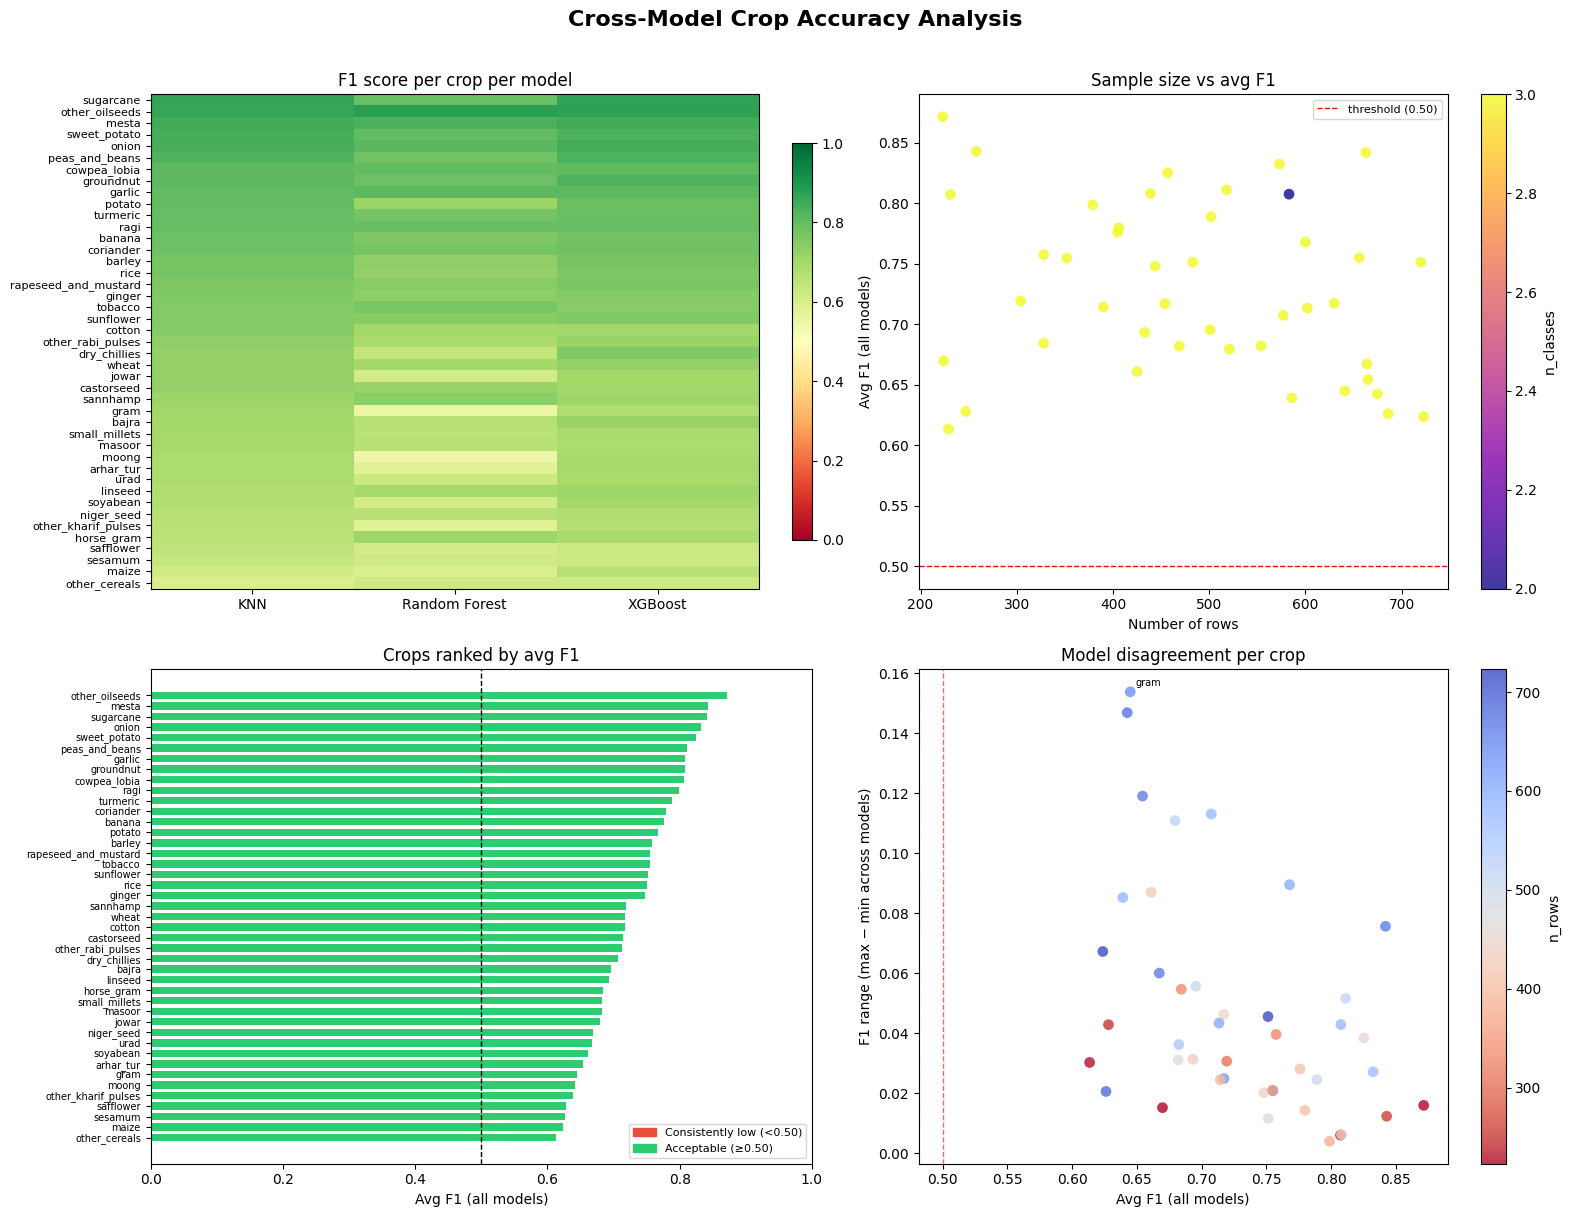

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Cross-Model Crop Accuracy Analysis", fontsize=16, fontweight='bold', y=1.01)

# ── 1. Heatmap: F1 per crop per model ──────────────────────────────────────
ax = axes[0, 0]
heatmap_data = merged[["f1_mean_knn", "f1_mean_rf", "f1_mean_xgb"]].values
crops = merged["crop"].values
im = ax.imshow(heatmap_data, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["KNN", "Random Forest", "XGBoost"])
ax.set_yticks(range(len(crops)))
ax.set_yticklabels(crops, fontsize=8)
ax.set_title("F1 score per crop per model")
plt.colorbar(im, ax=ax, fraction=0.03)
ax.axvline(x=-0.5, color='white', lw=0.5)

# ── 2. Scatter: n_rows vs avg F1, coloured by n_classes ────────────────────
ax = axes[0, 1]
sc = ax.scatter(
    merged["n_rows_knn"], merged["f1_avg_all"],
    c=merged["n_classes_knn"], cmap="plasma",
    s=60, alpha=0.8, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label="n_classes")
ax.axhline(y=0.50, color='red', linestyle='--', linewidth=1, label='threshold (0.50)')
for _, row in merged[merged["consistently_low"]].iterrows():
    ax.annotate(row["crop"], (row["n_rows_knn"], row["f1_avg_all"]),
                fontsize=7, xytext=(4, 4), textcoords='offset points', color='red')
ax.set_xlabel("Number of rows")
ax.set_ylabel("Avg F1 (all models)")
ax.set_title("Sample size vs avg F1")
ax.legend(fontsize=8)

# ── 3. Bar: avg F1 per crop, sorted, coloured by consistently_low ──────────
ax = axes[1, 0]
sorted_df = merged.sort_values("f1_avg_all")
colors = ["#e74c3c" if low else "#2ecc71" for low in sorted_df["consistently_low"]]
bars = ax.barh(sorted_df["crop"], sorted_df["f1_avg_all"], color=colors, height=0.7)
ax.axvline(x=0.50, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Avg F1 (all models)")
ax.set_title("Crops ranked by avg F1")
ax.set_xlim(0, 1)
ax.tick_params(axis='y', labelsize=7)
low_patch = mpatches.Patch(color='#e74c3c', label='Consistently low (<0.50)')
ok_patch  = mpatches.Patch(color='#2ecc71', label='Acceptable (≥0.50)')
ax.legend(handles=[low_patch, ok_patch], fontsize=8)

# ── 4. Scatter: model divergence — which crops split models apart ───────────
ax = axes[1, 1]
merged["f1_range"] = merged[["f1_mean_knn", "f1_mean_rf", "f1_mean_xgb"]].max(axis=1) \
                   - merged[["f1_mean_knn", "f1_mean_rf", "f1_mean_xgb"]].min(axis=1)
sc2 = ax.scatter(
    merged["f1_avg_all"], merged["f1_range"],
    c=merged["n_rows_knn"], cmap="coolwarm_r",
    s=60, alpha=0.8, edgecolors='none'
)
plt.colorbar(sc2, ax=ax, label="n_rows")
ax.axvline(x=0.50, color='red', linestyle='--', linewidth=1, alpha=0.6)
for _, row in merged[merged["f1_range"] > 0.15].iterrows():
    ax.annotate(row["crop"], (row["f1_avg_all"], row["f1_range"]),
                fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel("Avg F1 (all models)")
ax.set_ylabel("F1 range (max − min across models)")
ax.set_title("Model disagreement per crop")

plt.tight_layout()
plt.savefig("cross_model_crop_pattern_analysis.png", dpi=150, bbox_inches="tight")
plt.show()